File to view plots and mess around with interesting results without having to run code I don't care about for this purpose.


In [6]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Get the directory where you are currently working
current_path = os.getcwd()

# Join it with '..' to go up one level to the main folder
parent_path = os.path.abspath(os.path.join(current_path, '..'))

# Add it to sys.path
if parent_path not in sys.path:
    sys.path.insert(0, parent_path)

import numpy as np
import scipy as sp
from conversions import cm_to_m, erg_to_joule
from rr_escape import get_rr_escape_diagnostics, examine_atmosphere_for_rr_escape
from atmospheres.atmosphere_setting import Atmosphere, wind_microphysics
from bulk_param_examination import make_simple_atmosphere, sweep_parameter
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from stellar_cradle import get_L_x, solar_mass, mass_to_luminosity, get_F






The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<>:61: SyntaxWarning: invalid escape sequence '\o'
<>:61: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\2203884233.py:61: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)


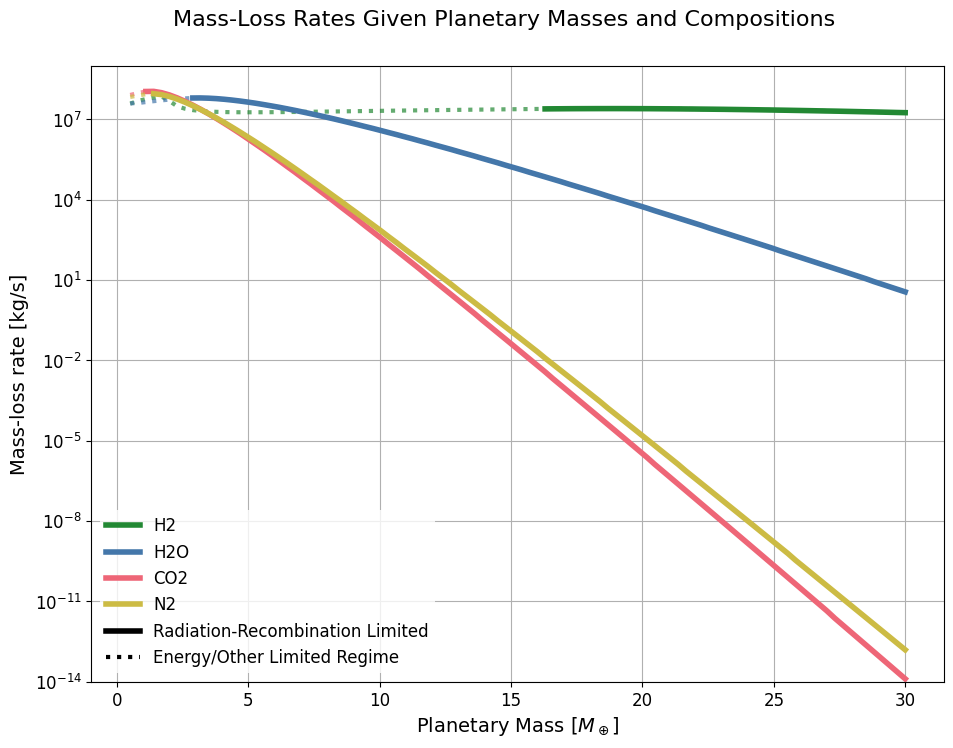

In [7]:
#I want to plot and compare how planets of different compositions


### Want to examine how planetary mass affects mass loss rate ###
M_earth = 5.9722 * 10**24               #[kg]        mass of the earth
Mass_array = np.linspace(0.5, 30, 100, endpoint=True) * M_earth #[kg] array of planetary masses from 0.5 to 30 times the mass of the earth


species_microphysics = {
    #NB, these are the values for the singly ionised and fully dissociated equivalents!!!!!
    'H2': {'nu_0': 3.288467085473 * 10**15, 'mu_wind': 0.5, 'mu_plus_wind': 1, 'mu_photo': 2},
    'H2O': {'nu_0': 4.835981008048 * 10**15 , 'mu_wind': 3, 'mu_plus_wind': 6, 'mu_photo': 18},
    'CO2' : {'nu_0' : 3.3368 * 10**15, 'mu_wind': 7.2, 'mu_plus_wind': 14.4, 'mu_photo': (12+(16*2))}, 
    'N2' : {'nu_0' : 3.7721 * 10**15, 'mu_wind': 7, 'mu_plus_wind': 14, 'mu_photo': 14*2}
    }

atmospheres_swept_varied_mass = {}
for species in species_microphysics.keys(): #for each species
    atms_varied_mass = np.array([make_simple_atmosphere( #make at atmosphere where only the mass is varied
        M_p=m,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=10000,
        dominant_species=species) for m in Mass_array])

    #now we have an array of atmospheres with different masses, we can sweep through them and get the mass loss rates and check if it is rr_limited
    M_dot_rr, regime_break, rr_mask = sweep_parameter(atms_varied_mass)
    atmospheres_swept_varied_mass[species] = (M_dot_rr, regime_break, rr_mask)


keys = list(atmospheres_swept_varied_mass.keys())

colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
fig.suptitle('Mass-Loss Rates Given Planetary Masses and Compositions', fontsize=16, y=0.95)
masses = Mass_array / M_earth

for i, species in enumerate(keys):
    mass_loss_rates, regime_break, rr_mask = atmospheres_swept_varied_mass[species]
    #plotting the whole mass loss rate curve as dotted first
    ax.plot(masses, mass_loss_rates, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
    #then plotting the part that is rr_limited as solid
    ax.plot(masses[rr_mask], np.array(mass_loss_rates)[rr_mask], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

# Get current handles and append our style definitions to the legend
handles, labels = ax.get_legend_handles_labels()
handles.extend(custom_lines)
labels.extend(['Radiation-Recombination Limited', 'Energy/Other Limited Regime'])
ax.legend(handles=handles, labels=labels, loc='best', fontsize=12, frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)
ax.set_ylabel('Mass-loss rate [kg/s]', fontsize=14)
# increase size and number of ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=10)
ax.set_yscale('log')
ax.set_ylim(10**(-14), 10**9)
#plt.savefig('Keepers/Mass_sweep.png', dpi=300, bbox_inches='tight')
plt.show()



<>:45: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\3277484100.py:45: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)


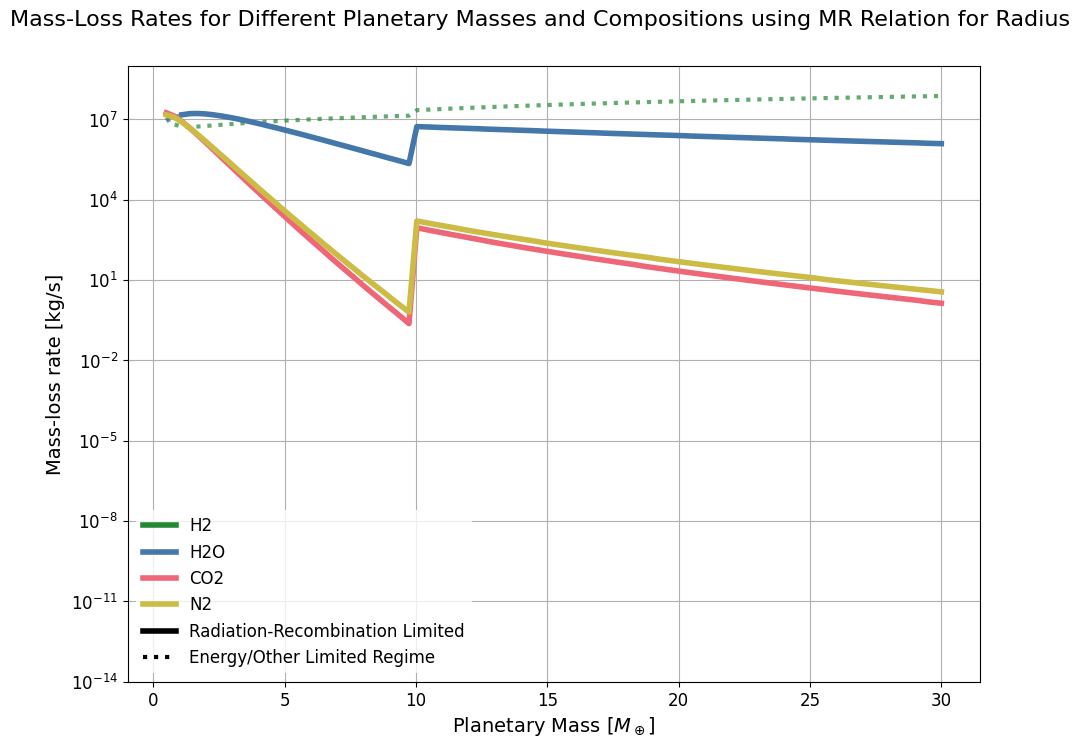

GJ1214b radius from MR relation: 1.2e+07 m
Actual GJ1214b radius: 1.8e+07 m
Mass loss rate for H2 with MR relation: 1.2e+07 kg/s


In [8]:
atmospheres_swept_varied_mass_MR = {}
for species in species_microphysics.keys(): #for each species
    atms_varied_mass_MR = np.array([make_simple_atmosphere( #make at atmosphere where only the mass is varied, but now the radius is determined by an MR relation
        M_p=m,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        dominant_species=species,
        resolution=10000,
        determine_radius=True) for m in Mass_array])

    #now we have an array of atmospheres with different masses, we can sweep through them and get the mass loss rates and check if it is rr_limited
    M_dot_rr, regime_break, rr_mask = sweep_parameter(atms_varied_mass_MR)
    atmospheres_swept_varied_mass_MR[species] = (M_dot_rr, regime_break, rr_mask)


keys = list(atmospheres_swept_varied_mass_MR.keys())

colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
fig.suptitle('Mass-Loss Rates for Different Planetary Masses and Compositions using MR Relation for Radius',  fontsize=16, y=0.95)
masses = Mass_array / M_earth

for i, species in enumerate(keys):
    mass_loss_rates_MR, regime_break_MR, rr_mask_MR = atmospheres_swept_varied_mass_MR[species]
    #plotting the whole mass loss rate curve as dotted first
    ax.plot(masses, mass_loss_rates_MR, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
    #then plotting the part that is rr_limited as solid
    ax.plot(masses[rr_mask_MR], np.array(mass_loss_rates_MR)[rr_mask_MR], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

# Get current handles and append our style definitions to the legend
handles, labels = ax.get_legend_handles_labels()
handles.extend(custom_lines)
labels.extend(['Radiation-Recombination Limited', 'Energy/Other Limited Regime'])
ax.legend(handles=handles, labels=labels, loc='best', fontsize=12, frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)
ax.set_ylabel('Mass-loss rate [kg/s]', fontsize=14)
# increase size and number of ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=10)
ax.set_ylim(10**(-14), 10**9)
ax.set_yscale('log')
#plt.savefig('Keepers/Mass_sweep_MR.png', dpi=300)
plt.show()

gj1214b_radius_MR = Atmosphere.determine_radius_from_MR_relation(8.41 * 5.9722 * 10**24 )
print(f'GJ1214b radius from MR relation: {gj1214b_radius_MR:.2g} m')
print(f'Actual GJ1214b radius: {2.85 * 6.371 * 10**6:.2g} m')

print(f'Mass loss rate for {keys[0]} with MR relation: {atmospheres_swept_varied_mass_MR[keys[0]][0][0]:.2g} kg/s')


<>:81: SyntaxWarning: invalid escape sequence '\o'
<>:81: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\1663386097.py:81: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)


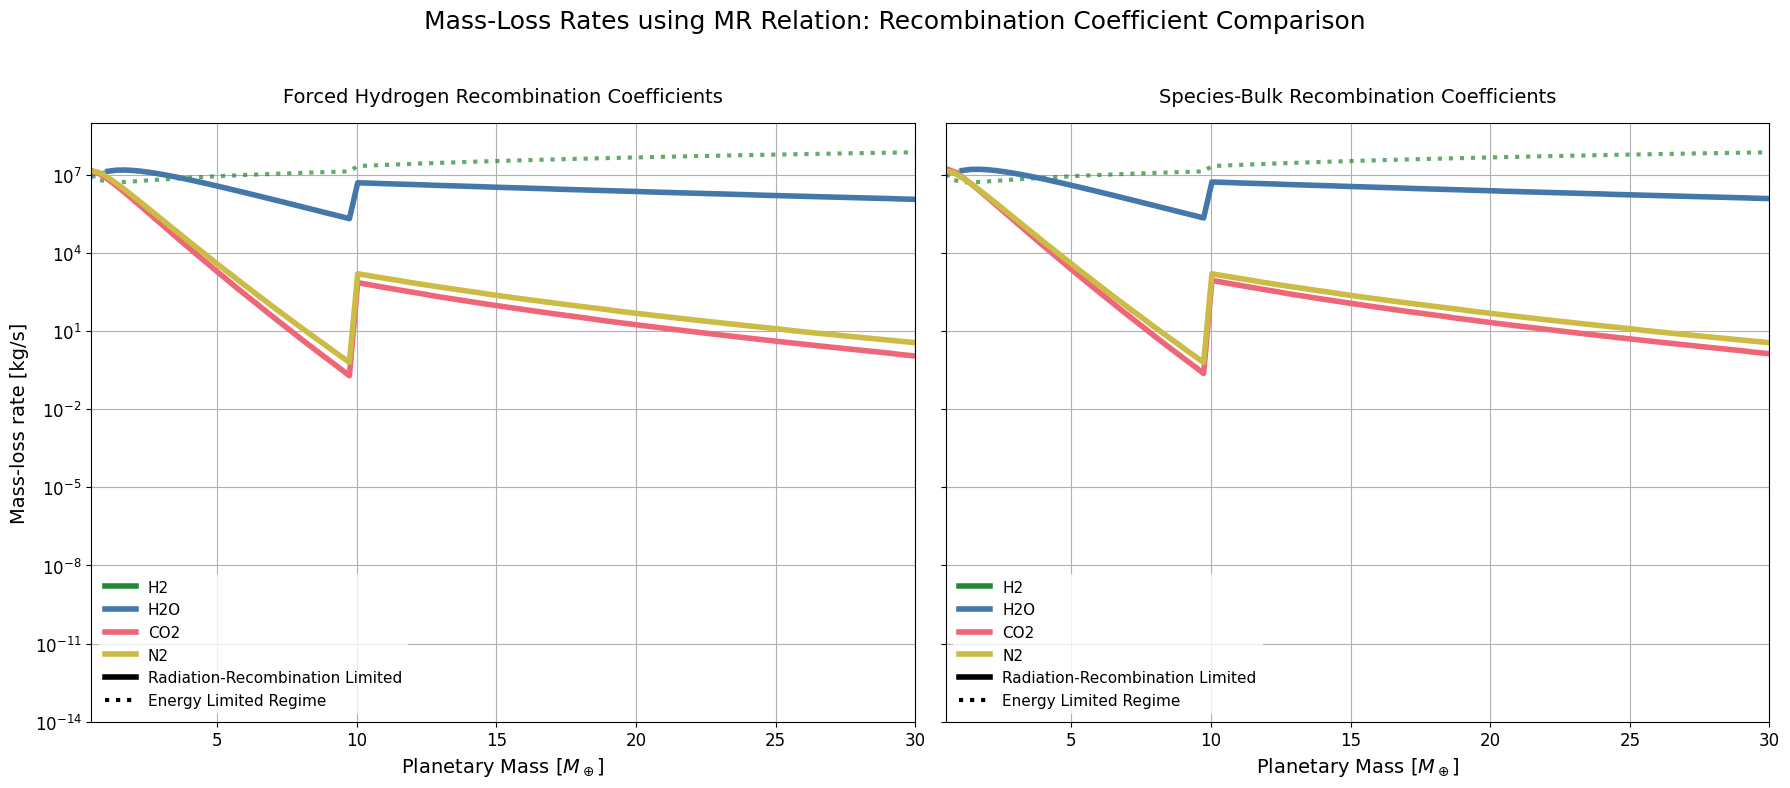

In [9]:
# 1. Initialize two separate dictionaries to store the sweeping results
results_H_coeff = {}
results_true_coeff = {}

for species in species_microphysics.keys(): 
    # --- RUN 1: FORCING HYDROGEN RECOMBINATION COEFFICIENTS ---
    atms_H_coeff = np.array([make_simple_atmosphere( 
        M_p=m,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=wind_microphysics[species]['nu_0'],
        mu_wind=wind_microphysics[species]['mu_wind'],
        mu_plus_wind=wind_microphysics[species]['mu_plus_wind'],
        rr_coeff=wind_microphysics['H2']['rr_coeff'], # <--- MANUAL OVERRIDE TO 'H2'
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        dominant_species=species,
        resolution=10000,
        determine_radius=True) for m in Mass_array])

    M_dot_rr_H, regime_break_H, rr_mask_H = sweep_parameter(atms_H_coeff)
    results_H_coeff[species] = (M_dot_rr_H, regime_break_H, rr_mask_H)

    # --- RUN 2: USING TRUE SPECIES RECOMBINATION COEFFICIENTS ---
    atms_true_coeff = np.array([make_simple_atmosphere( 
        M_p=m,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=wind_microphysics[species]['nu_0'],
        mu_wind=wind_microphysics[species]['mu_wind'],
        mu_plus_wind=wind_microphysics[species]['mu_plus_wind'],
        rr_coeff=wind_microphysics[species]['rr_coeff'], # <--- TRUE SPECIES COEFF
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        dominant_species=species,
        resolution=10000,
        determine_radius=True) for m in Mass_array])

    M_dot_rr_T, regime_break_T, rr_mask_T = sweep_parameter(atms_true_coeff)
    results_true_coeff[species] = (M_dot_rr_T, regime_break_T, rr_mask_T)


# --- 2. PLOTTING THE RESULTS SIDE-BY-SIDE ---
keys = list(species_microphysics.keys())
# Added a 5th colour just in case you have 5 species (H, H2, H2O, CO2, N2)
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44', '#9933A5'] 

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
fig.suptitle('Mass-Loss Rates using MR Relation: Recombination Coefficient Comparison', fontsize=18, y=0.98)
masses = Mass_array / M_earth

# Group the axes and data into lists so we can loop through them cleanly
axes = [ax1, ax2]
datasets = [results_H_coeff, results_true_coeff]
titles = ["Forced Hydrogen Recombination Coefficients", "Species-Bulk Recombination Coefficients"]

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

# Plot both subplots dynamically
for ax, data_dict, title in zip(axes, datasets, titles):
    ax.set_title(title, fontsize=14, pad=15)
    
    for i, species in enumerate(keys):
        mass_loss_rates, regime_break, rr_mask = data_dict[species]
        
        # plotting the whole mass loss rate curve as dotted first
        ax.plot(masses, mass_loss_rates, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
        # then plotting the part that is rr_limited as solid
        ax.plot(masses[rr_mask], np.array(mass_loss_rates)[rr_mask], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

    # Format the individual axes
    handles, labels = ax.get_legend_handles_labels()
    handles.extend(custom_lines)
    labels.extend(['Radiation-Recombination Limited', 'Energy Limited Regime'])
    ax.legend(handles=handles, labels=labels, loc='best', fontsize=11, frameon=True, shadow=False, facecolor='white', edgecolor='none')
    ax.grid(True)
    ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax.set_xlim(masses[0], masses[-1])

# Set the y-axis properties only on the first axis (since they share Y)
ax1.set_ylabel('Mass-loss rate [kg/s]', fontsize=14)
ax1.set_ylim(10**(-14), 10**9)
ax1.set_yscale('log')

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout so the suptitle doesn't overlap
#plt.savefig('Keepers/Mass_sweep_MR_Comparison.png', dpi=300)
plt.show()



<>:84: SyntaxWarning: invalid escape sequence '\o'
<>:84: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\2905136100.py:84: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)


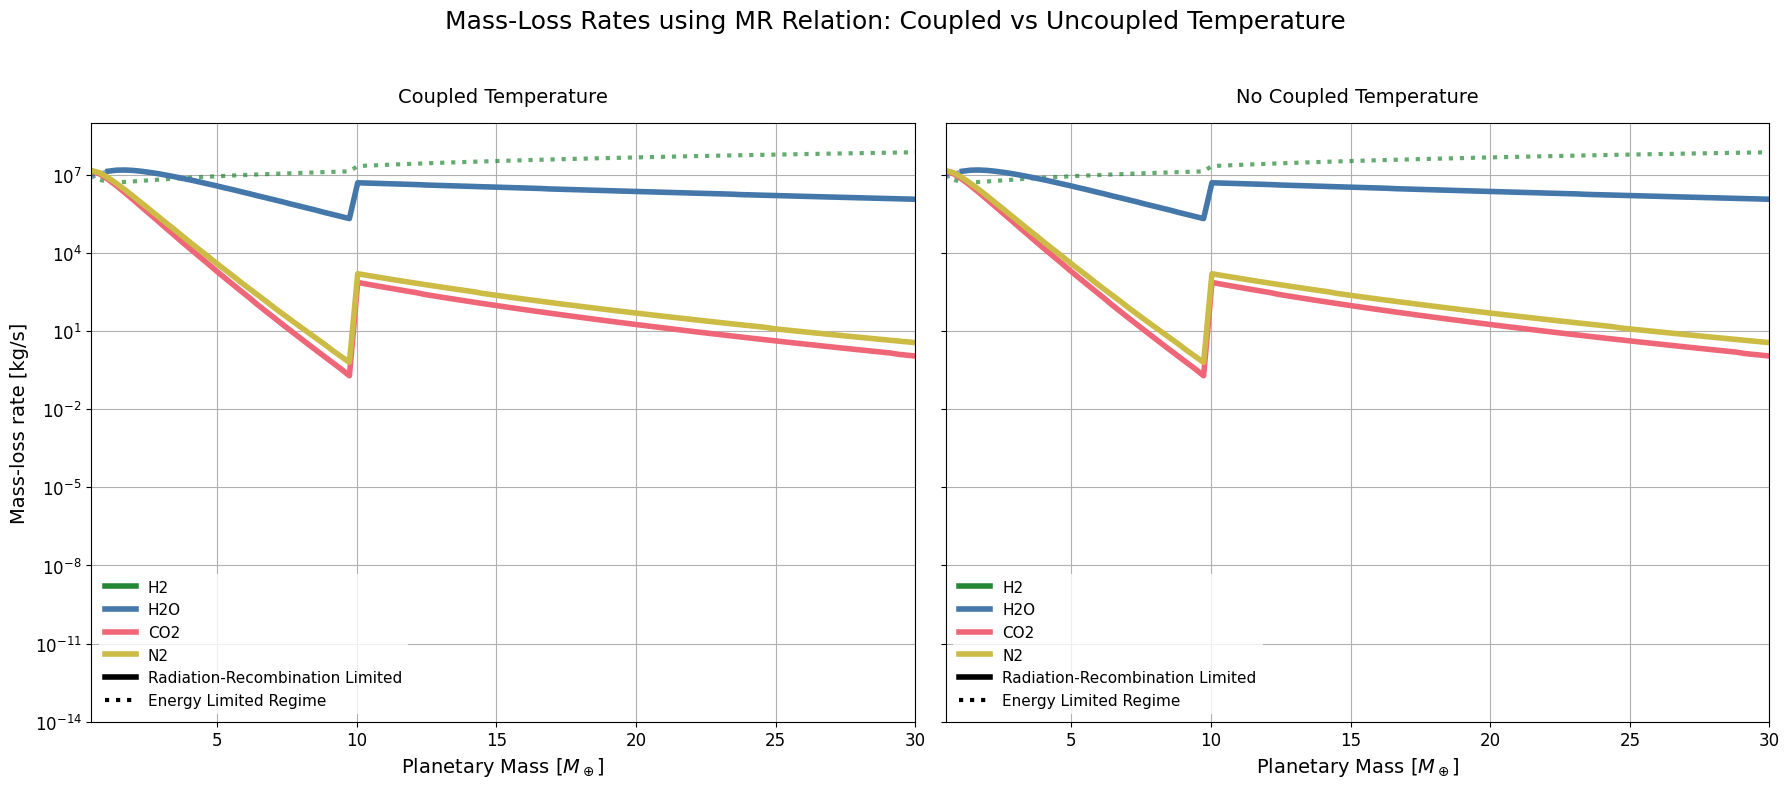

In [10]:
### See difference between coupling temperature and not coupling temperature when sweeping over mass and using MR relation ###

results_coupling_temp = {}
results_no_coupling_temp = {}

for species in keys:
    atm_coupled_temp = np.array([make_simple_atmosphere(
        M_p=m,
        mu_wind=wind_microphysics[species]['mu_wind'],
        mu_plus_wind=wind_microphysics[species]['mu_plus_wind'],
        rr_coeff=wind_microphysics['H2']['rr_coeff'],
        dominant_species=species,
        resolution=5000,
        determine_radius=True,
        determine_temperature=True,
        mu_photo=species_microphysics[species]['mu_photo'],
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        F_ins = 2.15 * 10**4 #Wm^-2, same as GJ1214b
    ) for m in Mass_array])


    M_dot_rr_coupled, regime_break__coupled, rr_mask_coupled = sweep_parameter(atm_coupled_temp)
    results_coupling_temp[species] = (M_dot_rr_coupled, regime_break__coupled, rr_mask_coupled)


    atm_no_coupling_temp = np.array([make_simple_atmosphere(
        M_p=m,
        mu_wind=wind_microphysics[species]['mu_wind'],
        mu_plus_wind=wind_microphysics[species]['mu_plus_wind'],
        rr_coeff=wind_microphysics['H2']['rr_coeff'],
        dominant_species=species,
        resolution=5000,
        determine_radius=True,
        T_eq = 553,
        determine_temperature=False,
        mu_photo=species_microphysics[species]['mu_photo'],
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        F_ins = 2.15 * 10**4 #Wm^-2, same as GJ1214b
    ) for m in Mass_array])



    M_dot_rr_no_coupling, regime_break_no_coupling, rr_mask_no_coupling = sweep_parameter(atm_no_coupling_temp)
    results_no_coupling_temp[species] = (M_dot_rr_no_coupling, regime_break_no_coupling, rr_mask_no_coupling)



# --- 2. PLOTTING THE RESULTS SIDE-BY-SIDE ---
keys = list(species_microphysics.keys())
# Added a 5th colour just in case you have 5 species (H, H2, H2O, CO2, N2)
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44', '#9933A5'] 

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
fig.suptitle('Mass-Loss Rates using MR Relation: Coupled vs Uncoupled Temperature', fontsize=18, y=0.98)
masses = Mass_array / M_earth

# Group the axes and data into lists so we can loop through them cleanly
axes = [ax1, ax2]
datasets = [results_coupling_temp, results_no_coupling_temp]
titles = ["Coupled Temperature", "No Coupled Temperature"]

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

# Plot both subplots dynamically
for ax, data_dict, title in zip(axes, datasets, titles):
    ax.set_title(title, fontsize=14, pad=15)
    
    for i, species in enumerate(keys):
        mass_loss_rates, regime_break, rr_mask = data_dict[species]
        
        # plotting the whole mass loss rate curve as dotted first
        ax.plot(masses, mass_loss_rates, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
        # then plotting the part that is rr_limited as solid
        ax.plot(masses[rr_mask], np.array(mass_loss_rates)[rr_mask], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

    # Format the individual axes
    handles, labels = ax.get_legend_handles_labels()
    handles.extend(custom_lines)
    labels.extend(['Radiation-Recombination Limited', 'Energy Limited Regime'])
    ax.legend(handles=handles, labels=labels, loc='best', fontsize=11, frameon=True, shadow=False, facecolor='white', edgecolor='none')
    ax.grid(True)
    ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax.set_xlim(masses[0], masses[-1])

# Set the y-axis properties only on the first axis (since they share Y)
ax1.set_ylabel('Mass-loss rate [kg/s]', fontsize=14)
ax1.set_ylim(10**(-14), 10**9)
ax1.set_yscale('log')

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout so the suptitle doesn't overlap
#plt.savefig('Keepers/Mass_sweep_MR_Comparison.png', dpi=300)
plt.show()



<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\53485112.py:14: SyntaxWarning: invalid escape sequence '\c'
  ax.scatter(MR_masses[low_mass_mask], radii[low_mass_mask], label='R = $1.02 \cdot M_{{p,\oplus}}^{0.28}$', color='#0072b2')
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\53485112.py:15: SyntaxWarning: invalid escape sequence '\c'
  ax.scatter(MR_masses[intermediate_mass_mask], radii[intermediate_mass_mask], label='R = $0.61 \cdot M_{{p,\oplus}}^{0.67}$', color='#cc79a7')
C:

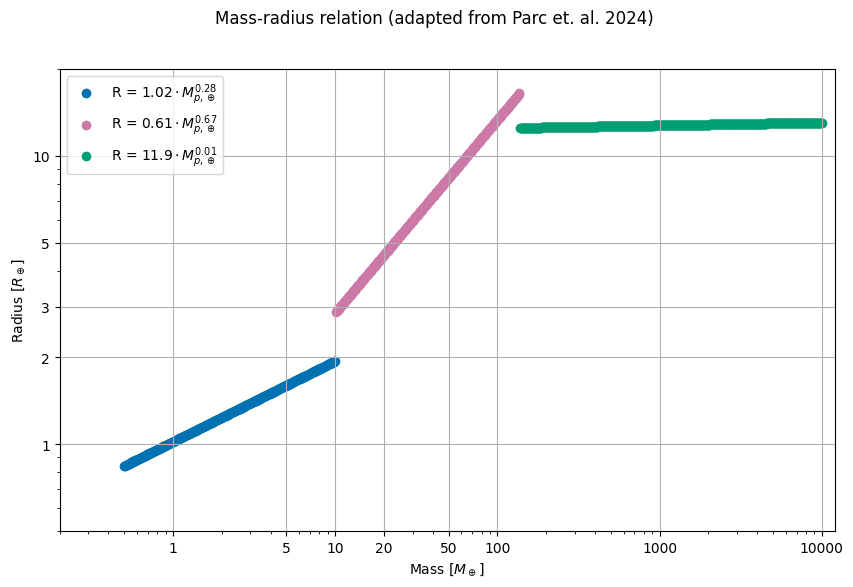

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
fig.suptitle('Mass-radius relation (adapted from Parc et. al. 2024)')
#Setting up the masses and radii we want to plot the relation of
R_earth = 6371000 #[m] mean earth radius
MR_masses = np.logspace(-0.3, 4, 1000) #[M_earth]
radii = np.array([Atmosphere.determine_radius_from_MR_relation(m)/R_earth for m in (MR_masses * M_earth)])

#Creating the masks
low_mass_mask = MR_masses < 10 #needs to be divided by earth masses again because the comparison is in earth masses
intermediate_mass_mask =  (MR_masses >= 10) & (MR_masses < 138)
high_mass_mask = MR_masses >= 138

#plotting the masks
ax.scatter(MR_masses[low_mass_mask], radii[low_mass_mask], label='R = $1.02 \cdot M_{{p,\oplus}}^{0.28}$', color='#0072b2')
ax.scatter(MR_masses[intermediate_mass_mask], radii[intermediate_mass_mask], label='R = $0.61 \cdot M_{{p,\oplus}}^{0.67}$', color='#cc79a7')
ax.scatter(MR_masses[high_mass_mask], radii[high_mass_mask], label='R = $11.9 \cdot M_{{p,\oplus}}^{0.01}$', color='#009e73')

#Switching axes to log scales
ax.set_xscale('log')
ax.set_yscale('log')

#Defineing and forcing the exact tick marks seen in the paper by Parc et. al. 2024
x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])

y_ticks = [1, 2, 3, 5, 10]
ax.set_yticks(y_ticks, labels=[str(y) for y in y_ticks])

#Sets limits to frame the data like the paper's plot bounds
ax.set_xlim(0.2, 12000)
ax.set_ylim(0.5, 20)
ax.set_xlabel('Mass [$M_\oplus$]')
ax.set_ylabel('Radius [$R_\oplus$]')
ax.grid()
ax.legend()
#plt.savefig('Keepers/MR_relation.png', dpi=300)
plt.show()
plt.close(fig)

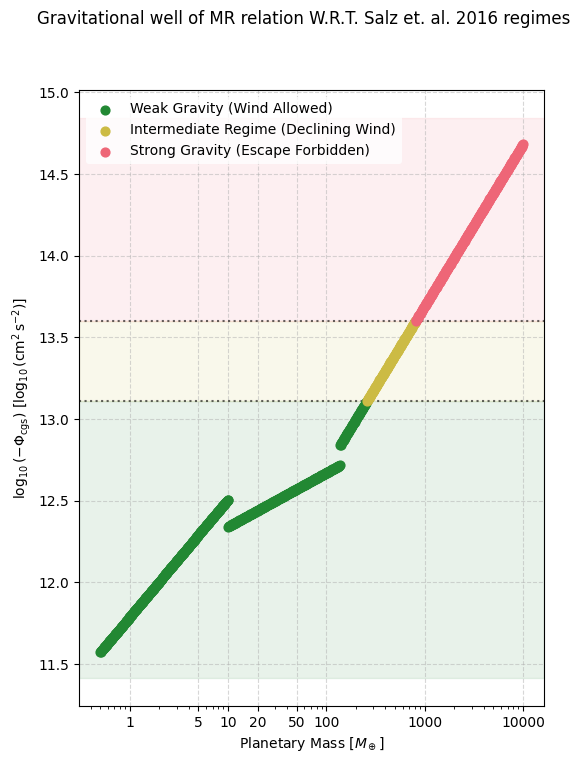

In [12]:
### Want to see how the gravitational well changes with the MR relation ###

### compare with salz et al 2016 if can host hydrodynamic escape ###
G = sp.constants.G #[m^3 kg^-1 s^-2]

grav_pot_SI = np.array([- G * m / Atmosphere.determine_radius_from_MR_relation(m) for m in (MR_masses * M_earth)]) #[m^2 s^-2] gravitational potential at the planetary radius, where G: gravitational constant, M_p: planetary mass, R_p: planetary radius
grav_pot_cgs = grav_pot_SI * cm_to_m**(-2) #[cm^2 s^-2] gravitational potential at the planetary radius in cgs units, where grav_pot_SI: gravitational potential at the planetary radius in SI units
grav_compare = np.log10(-grav_pot_cgs) #[log10(cm^2 s^-2)] logarithm of the negative gravitational potential at the planetary radius in cgs units, where grav_pot_cgs: gravitational potential at the planetary radius in cgs units
salz_strong_grav_threshold = 13.6 #Larger than this value and gravity is too high for hydrodynamic escape. No EL and no wind for RR. REFERENCE Salz et. al. 2016
salz_weak_grav_threshold = 13.11 #Smaller than this value and the planet can host hydrodynamic wind and therefore EL and RR.

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
fig.suptitle('Gravitational well of MR relation W.R.T. Salz et. al. 2016 regimes')

#Masks for the three possible regimes for the atmospheres:
weak_grav_mask = grav_compare < salz_weak_grav_threshold
strong_grav_mask = grav_compare > salz_strong_grav_threshold
intermediate_mask = (grav_compare >= salz_weak_grav_threshold) & (grav_compare <= salz_strong_grav_threshold)

ax.scatter(MR_masses[weak_grav_mask], grav_compare[weak_grav_mask], 
           color='#228833', s=40, zorder=3, label='Weak Gravity (Wind Allowed)')

ax.scatter(MR_masses[intermediate_mask], grav_compare[intermediate_mask], 
           color='#CCBB44', s=40, zorder=3, label='Intermediate Regime (Declining Wind)')

ax.scatter(MR_masses[strong_grav_mask], grav_compare[strong_grav_mask], 
           color='#EE6677', s=40, zorder=3, label='Strong Gravity (Escape Forbidden)')

#Visual Enhancements: Add Threshold Lines and Shading 
ax.axhline(salz_weak_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)
ax.axhline(salz_strong_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)

# Soft background color shading for each area
ax.axhspan(ax.get_ylim()[0], salz_weak_grav_threshold, color='#228833', alpha=0.1, zorder=1)
ax.axhspan(salz_weak_grav_threshold, salz_strong_grav_threshold, color='#CCBB44', alpha=0.1, zorder=1)
ax.axhspan(salz_strong_grav_threshold, ax.get_ylim()[1], color='#EE6677', alpha=0.1, zorder=1)

#5 Labels and Formatting
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel(r'Planetary Mass [$M_\oplus$]')
ax.set_ylabel(r'$\log_{10}(-\Phi_\mathrm{cgs})$ [$\log_{10}(\mathrm{cm}^2\,\mathrm{s}^{-2})$]')
ax.semilogx()
x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])
# Place the legend in a clean spot
ax.legend(loc='best', frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
#plt.savefig('Keepers/GravPotential_vs_Regime_MR_relation.png', dpi=300)
plt.show()
plt.close()

<>:70: SyntaxWarning: invalid escape sequence '\o'
<>:70: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\581298666.py:70: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(' $F_{XUV,\oplus}$', fontsize=14)


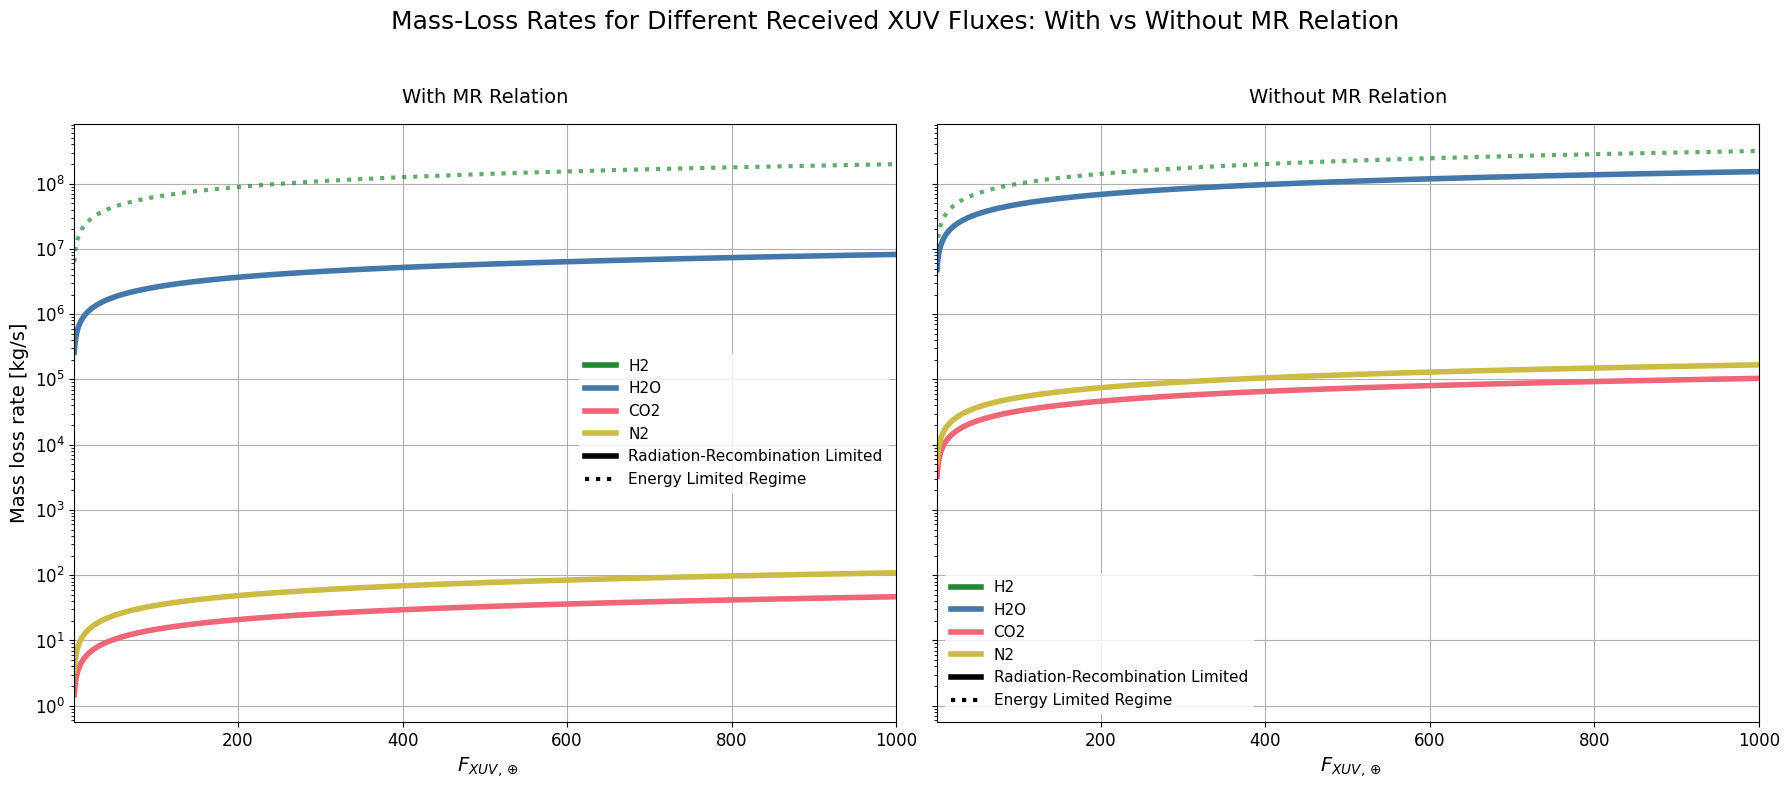

In [13]:
F_earth_xuv = 0.2196388835   #[W/m^2] XUV flux on Earth
Flux_array_xuv = np.logspace(0, 3, 1000) * F_earth_xuv #[W/m^2]
results_with_mr = {}
results_no_mr = {}

for species in species_microphysics.keys(): #for each species
    atm_with_mr = np.array([make_simple_atmosphere( #make at atmosphere where only the flux is varied but with MR relation
        M_p=8.41 * 5.9722 * 10**24,
        determine_radius=True,
        F_xuv=F,
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=5000,
        dominant_species=species) for F in Flux_array_xuv])

    M_dot_rr_with_mr, regime_break_with_mr, rr_mask_with_mr = sweep_parameter(atm_with_mr)
    results_with_mr[species] = (M_dot_rr_with_mr, regime_break_with_mr, rr_mask_with_mr)


    atm_no_mr = np.array([make_simple_atmosphere( #make at atmosphere where only the flux is varied but with no MR relation
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=F,
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=5000,
        dominant_species=species) for F in Flux_array_xuv])

    M_dot_rr_no_mr, regime_break_no_mr, rr_mask_no_mr = sweep_parameter(atm_no_mr)
    results_no_mr[species] = (M_dot_rr_no_mr, regime_break_no_mr, rr_mask_no_mr)

keys = list(results_with_mr.keys())
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44', '#9933A5'] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
fig.suptitle('Mass-Loss Rates for Different Received XUV Fluxes: With vs Without MR Relation', fontsize=18, y=0.98)
fluxes = Flux_array_xuv / F_earth_xuv

axes = [ax1, ax2]
datasets = [results_with_mr, results_no_mr]
titles = ["With MR Relation", "Without MR Relation"]

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

for ax, data_dict, title in zip(axes, datasets, titles):
    ax.set_title(title, fontsize=14, pad=15)
    
    for i, species in enumerate(keys):
        mass_loss_rates_flux, regime_break_flux, rr_mask_flux = data_dict[species]
        
        ax.plot(fluxes, mass_loss_rates_flux, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
        ax.plot(fluxes[rr_mask_flux], np.array(mass_loss_rates_flux)[rr_mask_flux], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

    handles, labels = ax.get_legend_handles_labels()
    handles.extend(custom_lines)
    labels.extend(['Radiation-Recombination Limited', 'Energy Limited Regime'])
    ax.legend(handles=handles, labels=labels, loc='best', fontsize=11, frameon=True, shadow=False, facecolor='white', edgecolor='none')
    ax.grid(True)
    ax.set_xlabel(' $F_{XUV,\oplus}$', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax.set_xlim(fluxes[0], fluxes[-1])

ax1.set_ylabel('Mass loss rate [kg/s]', fontsize=14)
ax1.set_yscale('log')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#plt.savefig('Keepers/Flux_sweep.png', dpi=300)
plt.show()

In [14]:
### See what happens when we sweep over flux with and without MR but now also couple the temperature to the bolometric flux ###



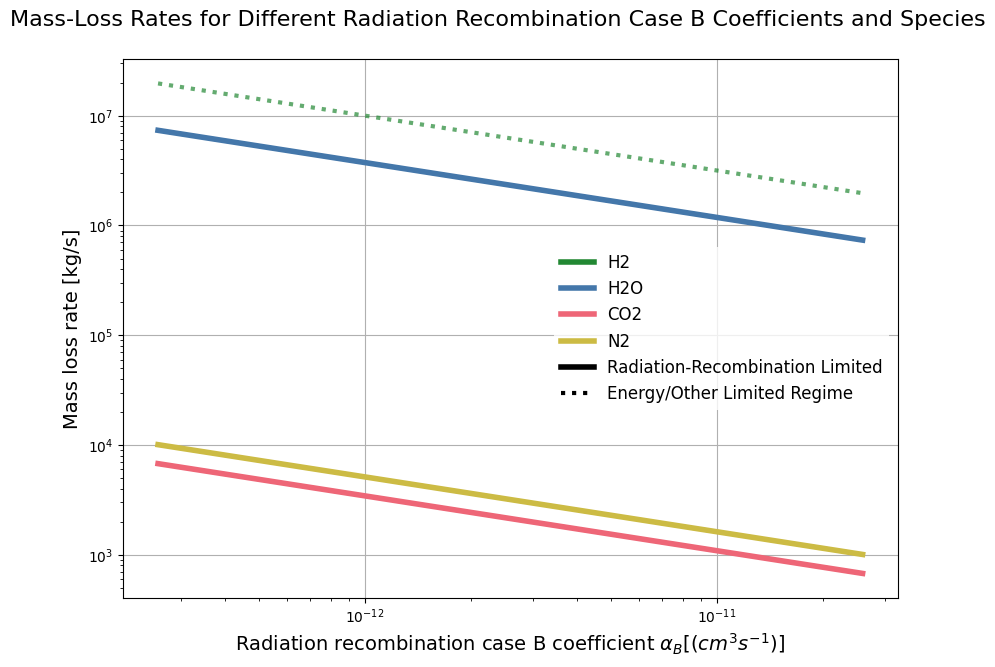

In [15]:
# I want to test the sensitivity of the recombination coefficient when it comes to the RR_escape rate value

#for different species with different coefficients, I want to plot the escape rate as a function of the recombination coefficient

alpha_B = np.linspace(2.59 * 10**(-13), 2.59 * 10**(-11), 100) #[cm^3 s^-1] start is based on singly ionised hydrogen alpha_B, end is based on O IX alpha_B. Just to test if its worth implementing exact values.

atmospheres_swept_coeffs = {}
for species in species_microphysics.keys(): #See dictionary defined above for the microphysical parameters of each species in the second cell
    atm_varied_coeff = np.array([make_simple_atmosphere(
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        T_eq=553,
        mu_photo=species_microphysics[species]['mu_photo'],
        P_0=2000,
        T_wind=10**4,
        dominant_species=species,
        rr_coeff=a #input in cm^3 s^-1, but is converted inside the function for escape rate calculation to m^3 s^-1
    ) for a in alpha_B])
    
    rates, r_break, rr_mask = sweep_parameter(atm_varied_coeff)
    atmospheres_swept_coeffs[species] = (rates, r_break, rr_mask)

keys = list(atmospheres_swept_coeffs.keys())


colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Mass-Loss Rates for Different Radiation Recombination Case B Coefficients and Species' , fontsize=16, y=0.95)

for i, species in enumerate(keys):
    mass_loss_rates_alpha, regime_break_alpha, rr_mask_alpha = atmospheres_swept_coeffs[species]
    #plotting the whole mass loss rate curve as dotted first
    ax.plot(alpha_B, mass_loss_rates_alpha, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
    #then plotting the part that is rr_limited as solid
    ax.plot(alpha_B[rr_mask_alpha], np.array(mass_loss_rates_alpha)[rr_mask_alpha], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

# Get current handles and append our style definitions to the legend
handles, labels = ax.get_legend_handles_labels()
handles.extend(custom_lines)
labels.extend(['Radiation-Recombination Limited', 'Energy/Other Limited Regime'])
ax.legend(handles=handles, labels=labels, loc='best', fontsize=12, frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
ax.set_xlabel('Radiation recombination case B coefficient $\\alpha_{B} [(cm^3 s^{-1})]$', fontsize=14)
ax.set_ylabel('Mass loss rate [kg/s]', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
#plt.savefig('Keepers/RR_coeff_sensitivity.png', dpi=300)
plt.show()

    

In [16]:


atmospheres = {}
for species in species_microphysics.keys():
    atm = np.array([make_simple_atmosphere(
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        T_eq=553,
        mu_photo=species_microphysics[species]['mu_photo'],
        P_0=2000,
        T_wind=10**4,
        dominant_species=species)
        ])
    atmospheres[species] = atm

for species in atmospheres.keys():
    examine_atmosphere_for_rr_escape(atmospheres[species][0])

Examining the following atmosphere:
Dominant species at the base of the escaping atmosphere: H2
Dominant species used to set wind parameters: True
Bulk properties: M_p = 5e+25 kg, R_p = 1.7e+07 m, F_xuv = 0.85 W/m^2
Wind properties: T_wind = 1e+04 K, mu_wind = 0.50, nu_0 = 3.29e+15 Hz, mu_plus_wind = 1.00, rr_coeff = 2.6e-13 cm^3 s^-1
Photosphere properties: P_0 = 2e+03 Pa, T_eq = 5.5e+02 K

Planet can host hydrodynamic escape through wind: 12.284965810498718 < 13.11 (log10(grav pot [cm^2 s^-2])

Escape diagnostics for the atmosphere:
Using values from this P_base: 0.0001 Pa
R_base: 2.2e+07 m
c_s: 1.3e+04 m/s
R_s: 2.2e+07 m
Is it RR-limited? False
The calculated sonic point radius was 1e+07 m
rho_s: 2.6e-13 kg/m^3
Escape rate: 2e+07 kg/s
Examining the following atmosphere:
Dominant species at the base of the escaping atmosphere: H2O
Dominant species used to set wind parameters: True
Bulk properties: M_p = 5e+25 kg, R_p = 1.7e+07 m, F_xuv = 0.85 W/m^2
Wind properties: T_wind = 1e+04 K, 

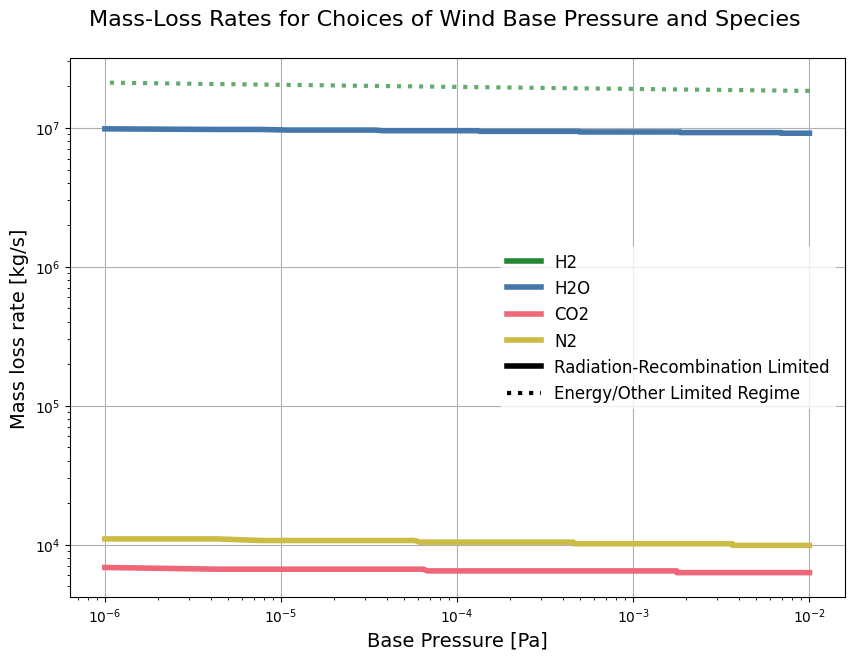

In [17]:
### Parameter sensitivity test for choice of P_base for RR escape rate calculation ###
P_base_array = np.linspace(10**(-2), 10**(-6), 3000) #[Pa] array of base pressures to test for the RR escape rate calculation, from 100 Pa to 10000 Pa. This is to test the sensitivity of the choice of base pressure for the RR escape rate calculation, which is currently set at 2000 Pa. We want to see if this choice affects the results significantly or not.

atmospheres_swept_P_base = {}
for species in species_microphysics.keys(): #See dictionary defined above for the microphysical parameters of each species in the second cell
    atm_varied_P_base = np.array([make_simple_atmosphere(
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        T_eq=553,
        mu_photo=species_microphysics[species]['mu_photo'],
        P_base=P_base,
        T_wind=10**4,
        dominant_species=species,
    ) for P_base in P_base_array])
    
    rates, r_break, rr_mask = sweep_parameter(atm_varied_P_base, check_P_base=True, sensitivity=4, target_P_base=P_base_array)
    atmospheres_swept_P_base[species] = (rates, r_break, rr_mask)

keys = list(atmospheres_swept_P_base.keys())


colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Mass-Loss Rates for Choices of Wind Base Pressure and Species' , fontsize=16, y=0.95)

for i, species in enumerate(keys):
    mass_loss_rates_P_base, regime_break_P_base, rr_mask_P_base = atmospheres_swept_P_base[species]
    #plotting the whole mass loss rate curve as dotted first
    ax.plot(P_base_array, mass_loss_rates_P_base, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
    #then plotting the part that is rr_limited as solid
    ax.plot(P_base_array[rr_mask_P_base], np.array(mass_loss_rates_P_base)[rr_mask_P_base], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

# Get current handles and append our style definitions to the legend
handles, labels = ax.get_legend_handles_labels()
handles.extend(custom_lines)
labels.extend(['Radiation-Recombination Limited', 'Energy/Other Limited Regime'])
ax.legend(handles=handles, labels=labels, loc='best', fontsize=12, frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
ax.set_xlabel('Base Pressure [Pa]', fontsize=14)
ax.set_ylabel('Mass loss rate [kg/s]', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
#plt.savefig('Keepers/RR_coeff_sensitivity.png', dpi=300)
plt.show()

<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:115: SyntaxWarning: invalid escape sequence '\o'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:115: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\457697852.py:113: SyntaxWarning: invalid escape sequence '\m'
  fig.supxlabel('Planetary Mass [$\mathrm{M}_\oplus$]', fontsize=18, y=0.03)
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\457697852.py:115: SyntaxWarning: invalid escape sequence '\o'
  fig.supylabel('Received XUV Flux [$F_{XUV,\oplus}$]', fontsize=18, x=0.03)


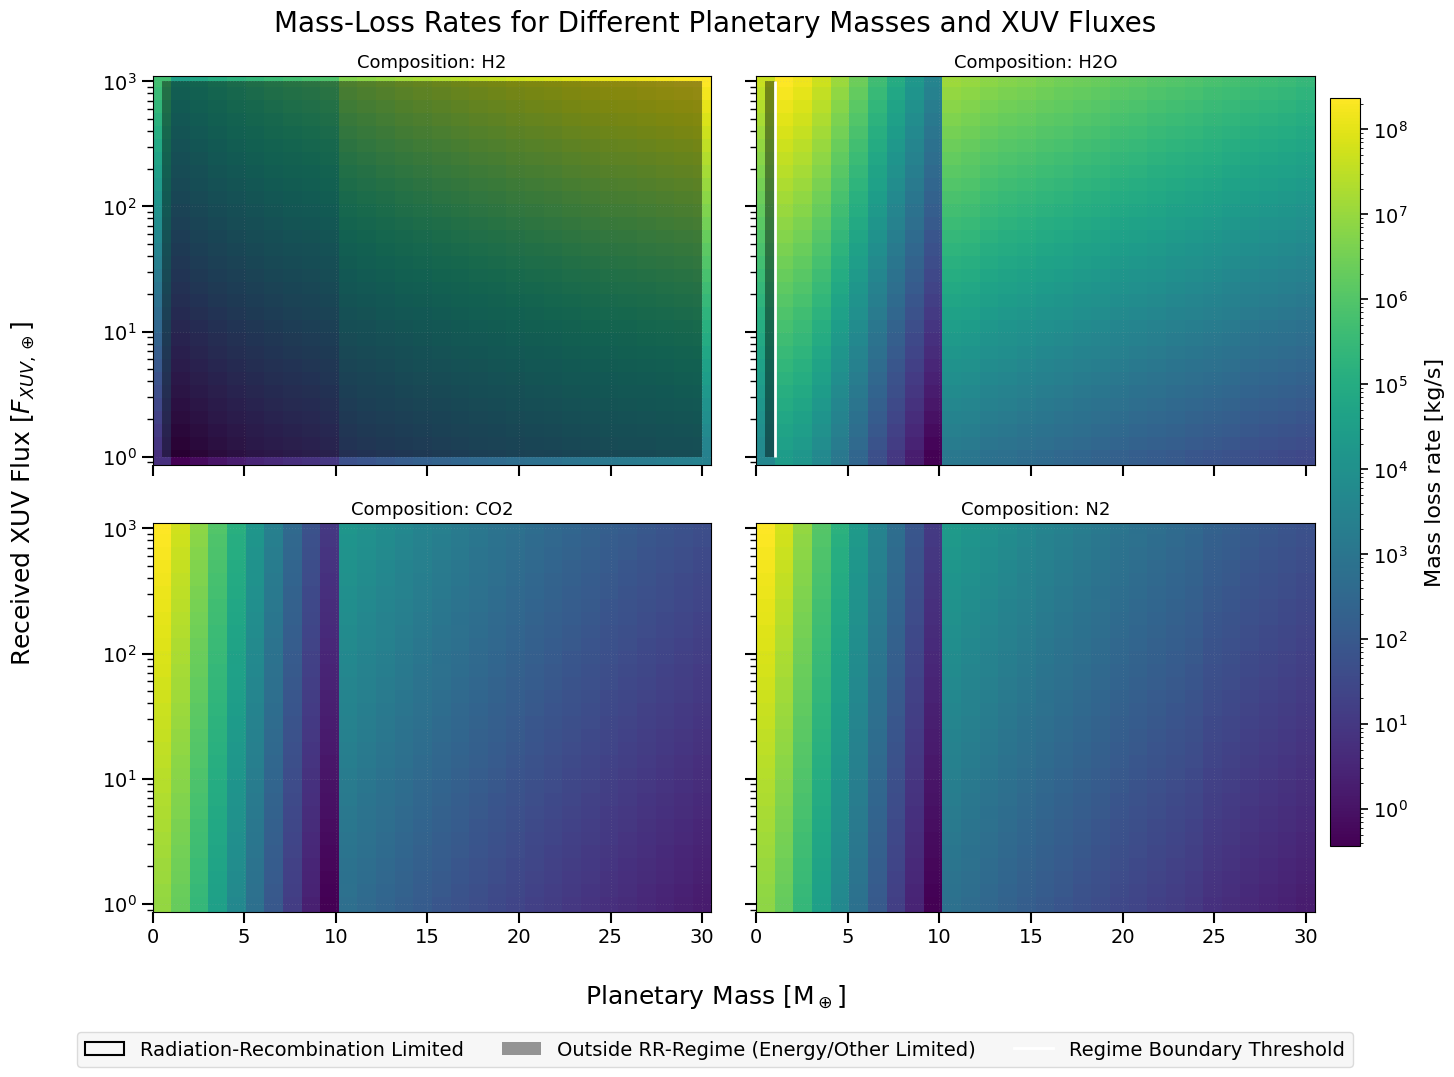

In [18]:
F_earth_xuv = 0.2196388835   #[W/m^2] XUV flux on Earth
M_earth = 5.9722 * 10**24               #[kg]        mass of the earth

# How many of each parameter to test for the sweep
n_masses = 30
n_fluxes = 30

# Generate the arrays of masses and fluxes to test
masses_2D = np.linspace(0.5, 30, n_masses) * M_earth         #[kg] array of planetary masses from 1 to 30 times the mass of the earth
fluxes_2D = np.logspace(0, 3, n_fluxes) * F_earth_xuv      #[W/m^2] array of XUV fluxes from 1 to 1000 times the XUV flux on Earth

# Dictionary to hold the atmospheres for each species and parameter combination
atmospheres_swept_2D = {}

# Loop through each species and create the atmospheres for each combination of mass and flux
for species in species_microphysics.keys():
    atms_varied_2D = np.array([[make_simple_atmosphere(
        M_p=M,
        determine_radius=True, #let the radius be determined by the MR relation for each mass
        F_xuv=F,
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=1000,
        dominant_species=species) for F in fluxes_2D] for M in masses_2D])

    # Must flatten the 2D array of atmospheres to pass to the sweep_parameter function, which expects a 1D array
    atms_varied_flat = atms_varied_2D.flatten()

    # Sweep through the atmospheres and get the mass loss rates and check if it is rr_limited
    M_dot_flat, regime_break, rr_mask_flat = sweep_parameter(atms_varied_flat)

    # Reshape the results back to 2D arrays for analysis and plotting
    M_dot_2D = np.array(M_dot_flat).reshape((n_masses, n_fluxes))
    rr_mask_2D = np.array(rr_mask_flat).reshape((n_masses, n_fluxes))

    atmospheres_swept_2D[species] = {'M_dot_rr': M_dot_2D, 'regime_break': regime_break, 'rr_mask': rr_mask_2D }




keys = list(atmospheres_swept_2D.keys())

### Plotting ###
fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True, sharey=True)
# Must flatten the axes array so that the loop grabs the individal subplot axes correctly rather than extracting a row of axes at a time
axes = axes.flatten()

# Prepare the units for plotting by normalizing the masses and fluxes to Earth units
masses_plot = masses_2D / M_earth
fluxes_plot = fluxes_2D / F_earth_xuv

# Build 2D meshgrid coordinates
X, Y = np.meshgrid(masses_plot, fluxes_plot)

for i, species in enumerate(keys):
    # Each species is plotted in its own subplot, so we grab the corresponding axis for that subplot
    ax = axes[i]
    
    # Transpose the 2D arrays so rows align to Y (Flux) and columns align to X (Mass)
    Z_mdot = atmospheres_swept_2D[species]['M_dot_rr'].T
    Z_mask = atmospheres_swept_2D[species]['rr_mask'].T.astype(float)
    
    # Plot the underlying data
    pcm = ax.pcolormesh(X, Y, Z_mdot, norm=colors.LogNorm(), cmap='viridis')

    # This throws a 40% opaque black block over the non-RR limited data. Filled contour. Need 0.5 because matplotlib is used to continuous data and we want to separate the 0 and 1 values in the mask. The levels argument defines the thresholds for the contouring, so -0.5 to 0.5 means that all values below 0.5 (the non-RR limited regime) will be colored, while values above 0.5 (the RR limited regime) will not be colored by this contourf call.
    ax.contourf(X, Y, Z_mask, levels=[-0.5, 0.5], colors='black', alpha=0.4) 

    # Add an optional white boundary edge to separate the two regimes clearly. #make the line exactly on the boundary between boolean values True and False (1, 0 respectively)
    ax.contour(X, Y, Z_mask, levels=[0.5], colors='white', linewidths=2)
    
    # Set title for each subplot
    ax.set_title(f'Composition: {species}', fontsize=13)

    # Set axis label and formatting grid
    ax.set_yscale('log')
    ax.grid(True, alpha=0.15, linestyle=':')


    # Adjust tick mark dimensions and tick label font sizes
    # Major Ticks (The main grid numbers)
    ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.5)
    # Minor Ticks (Crucial for the log-scale Y-axis)
    ax.tick_params(axis='both', which='minor', labelsize=11, length=4, width=1.0)
    
# Create custom legend elements for the two regimes and the boundary line
# The active regime (RR limited)
active_patch = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, 
                              label='Radiation-Recombination Limited')
# The outside regime 
shaded_patch = mpatches.Patch(facecolor='black', alpha=0.4, edgecolor='none', 
                              label='Outside RR-Regime (Energy/Other Limited)')
# The boundary line
boundary_line = Line2D([0], [0], color='white', linewidth=2, linestyle='-', 
                       label='Regime Boundary Threshold')

# Places the legend globally at the bottom center of the figure, outside the subplots, with a soft gray background and a light border for better visibility
fig.legend(handles=[active_patch, shaded_patch, boundary_line], 
           loc='lower center', bbox_to_anchor=(0.5, -0.03), 
           ncol=3, fontsize=14, 
           frameon=True, facecolor='#f5f5f5', edgecolor='#d3d3d3') 

# Shrink the subplots to make room for the global labels and legend
plt.subplots_adjust(right=0.90, hspace=0.15, wspace=0.08, bottom=0.12)
# Setting Title
fig.suptitle('Mass-Loss Rates for Different Planetary Masses and XUV Fluxes', fontsize=20, y=0.94)
# Adds a single, large global X label at the very bottom
fig.supxlabel('Planetary Mass [$\mathrm{M}_\oplus$]', fontsize=18, y=0.03)
# Adds a single, large global Y label at the far left
fig.supylabel('Received XUV Flux [$F_{XUV,\oplus}$]', fontsize=18, x=0.03)

# Creates the axes bounding the colourbar 
cbar_ax = fig.add_axes([0.91, 0.18, 0.02, 0.68])
cbar = fig.colorbar(pcm, cax=cbar_ax)

# Styles the colorbar text and tick lines
cbar.set_label('Mass loss rate [kg/s]', fontsize=16, labelpad=12)
cbar_ax.tick_params(axis='y', which='major', labelsize=14, length=6, width=1.2)

#plt.savefig('Keepers/Mass_Flux_2D_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
### want to plot the same graph as above sweeping over mass and flux but now with the coupling of the temperature to the bolometric flux, to see how that changes the results. For now I only have x-ray flux to drive escape mechanism, but I think its good to test ###

# Lets say we have a G type star of mass 1 solar masses, and an age of 7 Myr
# To get different bolometric and therefore X_ray fluxes, we can vary the distance from the planet to the host star, which in turn will vary the equilibrum temperature of the planet.

### Stellar setup ##########################################################################################################################################################################
M_star = 1 * solar_mass #[kg] mass of the star
age_star = 7 * 10**6 #[yr] age of the star

au = 149597870700 #[m] distance from the sun to the earth
semi_major_axis = np.logspace(-2, 1, 30) * au #distance from the star to the planet. Most known exoplanets are found within 10 AU, so we will test distances from 0.01 AU to 10 AU.

L_bol = mass_to_luminosity(M_star) #[W] bolometric luminosity of the star, calculated from the mass-luminosity relation
L_x = get_L_x(M_star, age_star) #[W] X-ray luminosity of the star, calculated from the mass-age relation
F_x_array = get_F(L_x, semi_major_axis) #[W/m^2] X-ray flux of the star on the planet
F_bol_array = get_F(L_bol, semi_major_axis) #[W/m^2] bolometric flux of the star on the planet

### Atmosphere setup ##############################################################################################################################################################################

# We can use the same atmospheres as before but now we will couple the temperature to the bolometric flux, which is calculated from the distance to the star and the luminosity of the star. 

F_earth_xuv = 0.2196388835   #[W/m^2] XUV flux on Earth
M_earth = 5.9722 * 10**24               #[kg]        mass of the earth

# How many of each parameter to test for the sweep
n_masses = 30
n_fluxes = len(semi_major_axis) 

# Generate the arrays of masses and fluxes to test
masses_2D = np.linspace(0.5, 30, n_masses) * M_earth         #[kg] array of planetary masses from 1 to 30 times the mass of the earth
fluxes_2D = F_x_array      #[W/m^2] array of X-ray fluxes retrieved from relationships with the stellar mass and age, and the distance from the star to the planet

# Dictionary to hold the atmospheres for each species and parameter combination
atmospheres_swept_2D = {}

# Loop through each species and create the atmospheres for each combination of mass and flux
for species in species_microphysics.keys():
    atms_varied_2D = np.array([[make_simple_atmosphere(
        M_p=M,
        determine_radius=True, #let the radius be determined by the MR relation for each mass
        F_xuv=F_x,
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=Atmosphere.determine_temperature_from_bolometric_flux(F_bol=F_b), #couple the equilibrium temperature to the bolometric flux, which is calculated from the distance to the star and the luminosity of the star
        resolution=1000,
        dominant_species=species) for F_x, F_b in zip(fluxes_2D, F_bol_array)] for M in masses_2D])

    # Must flatten the 2D array of atmospheres to pass to the sweep_parameter function, which expects a 1D array
    atms_varied_flat = atms_varied_2D.flatten()

    # Sweep through the atmospheres and get the mass loss rates and check if it is rr_limited
    M_dot_flat, regime_break, rr_mask_flat = sweep_parameter(atms_varied_flat)

    # Reshape the results back to 2D arrays for analysis and plotting
    M_dot_2D = np.array(M_dot_flat).reshape((n_masses, n_fluxes))
    rr_mask_2D = np.array(rr_mask_flat).reshape((n_masses, n_fluxes))

    atmospheres_swept_2D[species] = {'M_dot_rr': M_dot_2D, 'regime_break': regime_break, 'rr_mask': rr_mask_2D }





<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\o'
<>:66: SyntaxWarning: invalid escape sequence '\o'
<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\2111697205.py:66: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle('Mass-Loss Rates for Different Planetary Masses and received X-ray fluxes with coupled equilibrium temperatures. \n Host star: 1 M$_\odot$', fontsize=20, y=0.94)
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\2111697205.py:68: SyntaxWarning: invalid escape sequence '\m'
  fig.supxlabel('Planetary Mass [$\mathrm{M}_\oplus$]', fontsize=18, y=0.03)
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\2111697205.py:70: SyntaxWarning: invalid escape sequence '\o'
  fig.supylabel('Received X-ray Flux [$F_{X,\oplus}$]', fontsize=18, x=0.03)


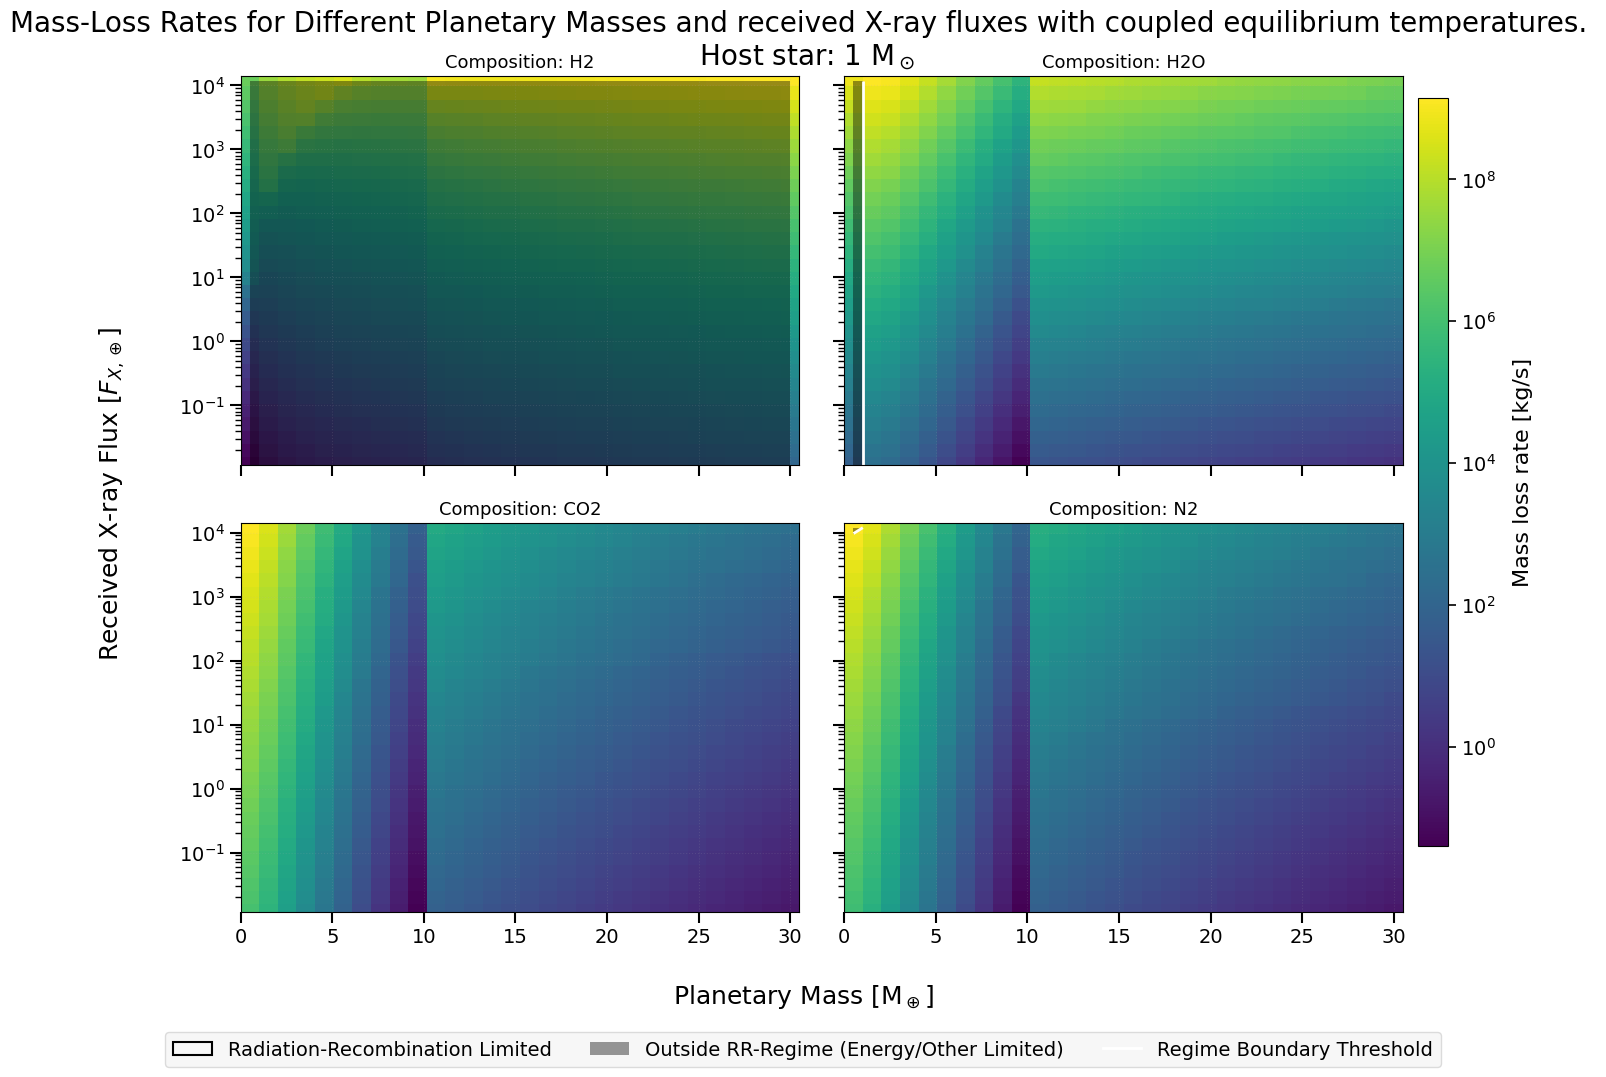

In [23]:


keys = list(atmospheres_swept_2D.keys())

### Plotting ###
fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True, sharey=True)
# Must flatten the axes array so that the loop grabs the individal subplot axes correctly rather than extracting a row of axes at a time
axes = axes.flatten()

# Prepare the units for plotting by normalizing the masses and fluxes to Earth units
masses_plot = masses_2D / M_earth
fluxes_plot = fluxes_2D / F_earth_xuv

# Build 2D meshgrid coordinates
X, Y = np.meshgrid(masses_plot, fluxes_plot)

for i, species in enumerate(keys):
    # Each species is plotted in its own subplot, so we grab the corresponding axis for that subplot
    ax = axes[i]
    
    # Transpose the 2D arrays so rows align to Y (Flux) and columns align to X (Mass)
    Z_mdot = atmospheres_swept_2D[species]['M_dot_rr'].T
    Z_mask = atmospheres_swept_2D[species]['rr_mask'].T.astype(float)
    
    # Plot the underlying data
    pcm = ax.pcolormesh(X, Y, Z_mdot, norm=colors.LogNorm(), cmap='viridis')

    # This throws a 40% opaque black block over the non-RR limited data. Filled contour. Need 0.5 because matplotlib is used to continuous data and we want to separate the 0 and 1 values in the mask. The levels argument defines the thresholds for the contouring, so -0.5 to 0.5 means that all values below 0.5 (the non-RR limited regime) will be colored, while values above 0.5 (the RR limited regime) will not be colored by this contourf call.
    ax.contourf(X, Y, Z_mask, levels=[-0.5, 0.5], colors='black', alpha=0.4) 

    # Add an optional white boundary edge to separate the two regimes clearly. #make the line exactly on the boundary between boolean values True and False (1, 0 respectively)
    ax.contour(X, Y, Z_mask, levels=[0.5], colors='white', linewidths=2)
    
    # Set title for each subplot
    ax.set_title(f'Composition: {species}', fontsize=13)

    # Set axis label and formatting grid
    ax.set_yscale('log')
    ax.grid(True, alpha=0.15, linestyle=':')


    # Adjust tick mark dimensions and tick label font sizes
    # Major Ticks (The main grid numbers)
    ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.5)
    # Minor Ticks (Crucial for the log-scale Y-axis)
    ax.tick_params(axis='both', which='minor', labelsize=11, length=4, width=1.0)
    
# Create custom legend elements for the two regimes and the boundary line
# The active regime (RR limited)
active_patch = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, 
                              label='Radiation-Recombination Limited')
# The outside regime 
shaded_patch = mpatches.Patch(facecolor='black', alpha=0.4, edgecolor='none', 
                              label='Outside RR-Regime (Energy/Other Limited)')
# The boundary line
boundary_line = Line2D([0], [0], color='white', linewidth=2, linestyle='-', 
                       label='Regime Boundary Threshold')

# Places the legend globally at the bottom center of the figure, outside the subplots, with a soft gray background and a light border for better visibility
fig.legend(handles=[active_patch, shaded_patch, boundary_line], 
           loc='lower center', bbox_to_anchor=(0.5, -0.03), 
           ncol=3, fontsize=14, 
           frameon=True, facecolor='#f5f5f5', edgecolor='#d3d3d3') 

# Shrink the subplots to make room for the global labels and legend
plt.subplots_adjust(right=0.90, hspace=0.15, wspace=0.08, bottom=0.12)
# Setting Title
fig.suptitle('Mass-Loss Rates for Different Planetary Masses and received X-ray fluxes with coupled equilibrium temperatures. \n Host star: 1 M$_\odot$', fontsize=20, y=0.94)
# Adds a single, large global X label at the very bottom
fig.supxlabel('Planetary Mass [$\mathrm{M}_\oplus$]', fontsize=18, y=0.03)
# Adds a single, large global Y label at the far left
fig.supylabel('Received X-ray Flux [$F_{X,\oplus}$]', fontsize=18, x=0.03)

# Creates the axes bounding the colourbar 
cbar_ax = fig.add_axes([0.91, 0.18, 0.02, 0.68])
cbar = fig.colorbar(pcm, cax=cbar_ax)

# Styles the colorbar text and tick lines
cbar.set_label('Mass loss rate [kg/s]', fontsize=16, labelpad=12)
cbar_ax.tick_params(axis='y', which='major', labelsize=14, length=6, width=1.2)

#plt.savefig('Keepers/Mass_Flux_2D_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

1
